In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import mlflow
import mlflow.lightgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from itertools import product

warnings.filterwarnings('ignore')

TARGET= 'consommation_telerelevee_professionnelle'

OTHERS= [
    'consommation_telerelevee_hta',
    'consommation_telerelevee_residentielle',
    'consommation_telerelevee_btsup',
]

HORIZON=7*48


In [2]:
df=pd.read_csv("C:/Users/T14s/Desktop/ml-project/data/features_with_lags.csv",parse_dates=['datetime'])
df = df.set_index('datetime')

In [3]:
df.columns

Index(['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend',
       'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee',
       'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend',
       'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim',
       'pseudo_rayonnement', 'consommation_telerelevee_hta',
       'consommation_telerelevee_btsup',
       'consommation_telerelevee_professionnelle',
       'consommation_telerelevee_residentielle', 'halfhour_of_day',
       'jour_fetes', 'consommation_telerelevee_hta_lag_336',
       'consommation_telerelevee_hta_lag_672',
       'consommation_telerelevee_hta_lag_1344',
       'consommation_telerelevee_btsup_lag_336',
       'consommation_telerelevee_btsup_lag_672',
       'consommation_telerelevee_btsup_lag_1344',
       'consommation_telerelevee_professionnelle_lag_336',
       'consommation_telerelevee_professionnelle_lag_672',
       'consommation_telerelevee_professionnelle_lag_1344',
       'co

In [4]:
featurs_col=['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend',
              'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee',
              'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend',
              'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim', 'jour_fetes',
              'week_index','activite_pro',
              'pseudo_rayonnement', 'consommation_telerelevee_professionnelle_lag_336',
              'consommation_telerelevee_professionnelle_lag_672',
              'consommation_telerelevee_professionnelle_lag_1344']
target='consommation_telerelevee_professionnelle'

In [5]:
X=df[featurs_col]
y=df[target]

In [6]:
X_train_full= X.iloc[:-HORIZON]  
X_test= X.iloc[-HORIZON:]   
y_train_full= y.iloc[:-HORIZON]
y_test= y.iloc[-HORIZON:]

In [7]:

print('Features finales :', featurs_col)
print('Nombre :', len(featurs_col))

X_train_final= X_train_full[featurs_col]
X_test_final= X_test[featurs_col]

Features finales : ['year_utc', 'month_utc', 'day', 'day_of_week', 'est_weekend', 'est_ferie', 'hour_utc', 'minute_utc', 'temperature_reelle_lissee', 'temperature_normale_lissee', 'ecart_temperature', 'temp_x_weekend', 'temp_x_ferier', 'degre_jour_chauffage', 'degre_jour_clim', 'jour_fetes', 'week_index', 'activite_pro', 'pseudo_rayonnement', 'consommation_telerelevee_professionnelle_lag_336', 'consommation_telerelevee_professionnelle_lag_672', 'consommation_telerelevee_professionnelle_lag_1344']
Nombre : 22


In [ ]:
PARAM_GRID = {
    'n_estimators': [900, 950],
    'max_depth': [13, 15],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'num_leaves': [100, 115],
}

keys= list(PARAM_GRID.keys())
values= list(PARAM_GRID.values())
combinations= [dict(zip(keys, v)) for v in product(*values)]

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=HORIZON 
)

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment('LightGBM_professionnelle01')

best_mae= float('inf')
best_params= None
results= []

for i, params in enumerate(combinations):

    fold_maes= []
    fold_rmses= []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_final)):

        X_cv_train= X_train_final.iloc[train_idx]
        y_cv_train= y_train_full.iloc[train_idx]
        X_cv_val= X_train_final.iloc[val_idx]
        y_cv_val= y_train_full.iloc[val_idx]

        model = LGBMRegressor(
            **params,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(
            X_cv_train, y_cv_train,
            eval_set=[(X_cv_val, y_cv_val)]
        )

        preds = model.predict(X_cv_val)
        fold_maes.append(mean_absolute_error(y_cv_val, preds))
        fold_rmses.append(np.sqrt(mean_squared_error(y_cv_val, preds)))

    mae_mean  = np.mean(fold_maes)
    mae_std   = np.std(fold_maes)
    rmse_mean = np.mean(fold_rmses)

    results.append({**params, 'mae_mean': mae_mean, 'mae_std': mae_std})

    with mlflow.start_run(run_name=f'run_{i+1:02d}'):
        mlflow.log_params(params)
        mlflow.log_param('target', TARGET)
        mlflow.log_param('n_features_selected', len(featurs_col))
        mlflow.log_param('horizon', 'J+7')

        mlflow.log_metric('cv_mae_mean', mae_mean)
        mlflow.log_metric('cv_mae_std', mae_std)
        mlflow.log_metric('cv_rmse_mean', rmse_mean)

        for f, m in enumerate(fold_maes):
            mlflow.log_metric(f'fold_{f+1}_mae', m)

    if mae_mean < best_mae:
        best_mae= mae_mean
        best_params= params

    print(f'  [{i+1:2d}/{len(combinations)}] MAE={mae_mean:.2f} ± {mae_std:.2f} | {params}')

print(f'\nGrid Search terminé')
print(f'Meilleurs paramètres: {best_params}')
print(f'Meilleure MAE CV: {best_mae:.2f}')


🏃 View run run_01 at: http://127.0.0.1:5000/#/experiments/9/runs/ee447a23b71844e1a080733c3761f7d7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/9
  [ 1/32] MAE=1518441.51 ± 657574.82 | {'n_estimators': 900, 'max_depth': 9, 'learning_rate': 0.05, 'subsample': 0.8, 'num_leaves': 90}
🏃 View run run_02 at: http://127.0.0.1:5000/#/experiments/9/runs/8aa00cddf7384f4f88023054e5b06342
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/9
  [ 2/32] MAE=1523539.85 ± 629546.55 | {'n_estimators': 900, 'max_depth': 9, 'learning_rate': 0.05, 'subsample': 0.8, 'num_leaves': 100}
🏃 View run run_03 at: http://127.0.0.1:5000/#/experiments/9/runs/e6526f993e1f4945ac347a3edd5737d7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/9
  [ 3/32] MAE=1518441.51 ± 657574.82 | {'n_estimators': 900, 'max_depth': 9, 'learning_rate': 0.05, 'subsample': 1.0, 'num_leaves': 90}
🏃 View run run_04 at: http://127.0.0.1:5000/#/experiments/9/runs/f872d2f9fb6b4dd6badabbf2c2913e83
🧪 View experiment a

2026/04/14 23:18:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MAE: 1,863,627
RMSE: 2,423,764
MAPE: 8.76%
R2: 0.2695


2026/04/14 23:18:57 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/9/runs/b0294f1951514521adc99cc572e67c89
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/9


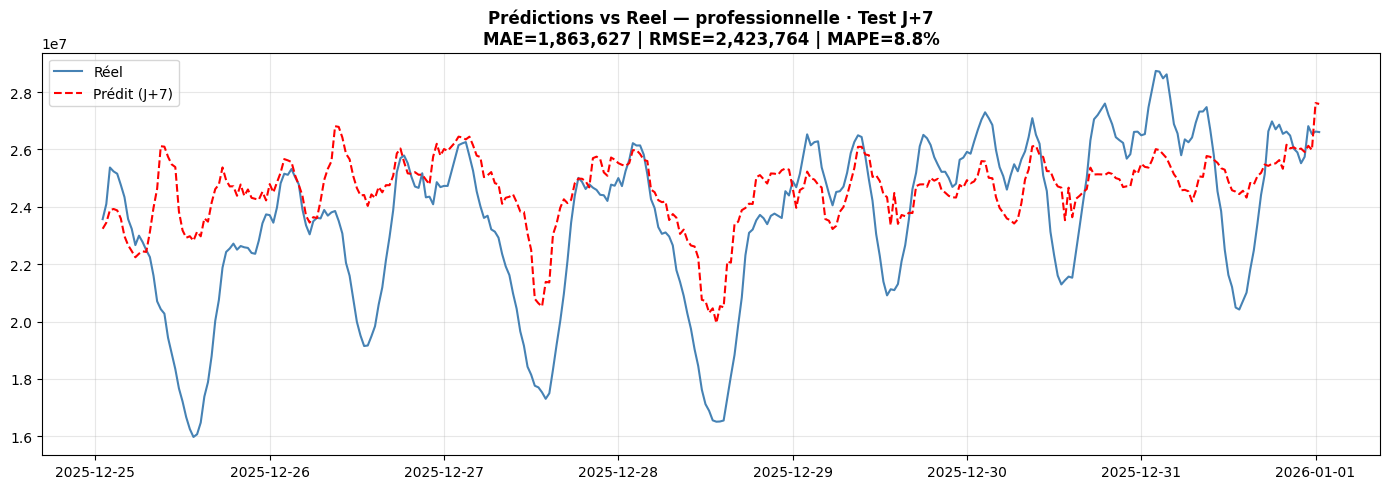

In [12]:
final_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)

train_recent = X_train_final[
    X_train_final.index >= '2023-01-01'
]
y_train_recent = y_train_full[
    y_train_full.index >= '2023-01-01'
]

final_model.fit(train_recent, y_train_recent)
y_pred= final_model.predict(X_test_final)
y_true_arr = np.array(y_test).flatten()
y_pred_arr = np.array(y_pred).flatten()

mae= mean_absolute_error(y_true_arr, y_pred_arr)
rmse= np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mape= np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100
r2= r2_score(y_true_arr, y_pred_arr)

print(f'MAE: {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.2f}%')
print(f'R2: {r2:.4f}')

with mlflow.start_run(run_name='FINAL_best_model'):
    mlflow.log_params(best_params)
    mlflow.log_param('target', TARGET)
    mlflow.log_param('n_features_selected', len(featurs_col))
    mlflow.log_param('features_selected', str(featurs_col))
    mlflow.log_param('horizon', 'J+7')

    mlflow.log_metric('test_mae', mae)
    mlflow.log_metric('test_rmse', rmse)
    mlflow.log_metric('test_mape', mape)
    mlflow.log_metric('cv_mae_best', best_mae)

    mlflow.lightgbm.log_model(final_model, 'model')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.index, y_test.values, 
        label='Réel', color='steelblue', linewidth=1.5)
ax.plot(y_test.index, y_pred, 
        label='Prédit (J+7)', color='red', linewidth=1.5, linestyle='--')

ax.set_title(f'Prédictions vs Reel — professionnelle · Test J+7\n'
             f'MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.1f}%',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

MAE: 1,863,627
RMSE: 2,423,764
MAPE: 8.76%
R2: 0.2695


2026/04/14 23:19:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 23:19:23 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/9/runs/8b9a4e28b6ae45559f8fc8d46e1bf72d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/9


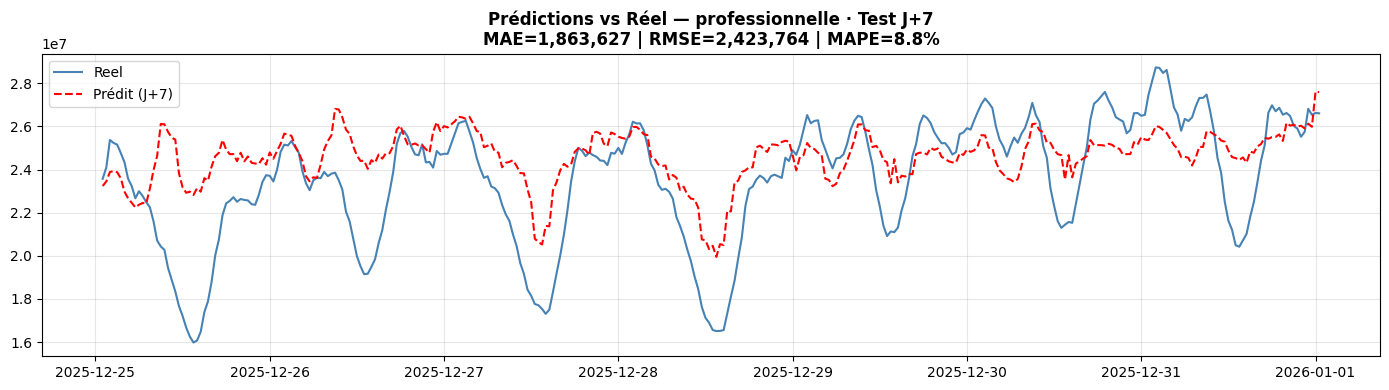

Registered model 'Enedis_professionnelle_LGB' already exists. Creating a new version of this model...
2026/04/14 23:19:30 WARNING mlflow.tracking._model_registry.fluent: Run with id 8b9a4e28b6ae45559f8fc8d46e1bf72d has no artifacts at artifact path 'model', registering model based on models:/m-8975661fcb1a4d95b586d55901313ee7 instead


🏃 View run FINAL_best_model at: http://127.0.0.1:5000/#/experiments/9/runs/8b9a4e28b6ae45559f8fc8d46e1bf72d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/9


2026/04/14 23:19:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Enedis_professionnelle_LGB, version 2
Created version '2' of model 'Enedis_professionnelle_LGB'.


<ModelVersion: aliases=[], creation_timestamp=1776205170363, current_stage='Production', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1776205170469, metrics=None, model_id=None, name='Enedis_professionnelle_LGB', params=None, run_id='8b9a4e28b6ae45559f8fc8d46e1bf72d', run_link='', source='models:/m-8975661fcb1a4d95b586d55901313ee7', status='READY', status_message=None, tags={}, user_id='', version='2', workspace='default'>

In [13]:
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

final_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
train_recent = X_train_final[
    X_train_final.index >= '2023-01-01'
]
y_train_recent = y_train_full[
    y_train_full.index >= '2023-01-01'
]

final_model.fit(train_recent, y_train_recent)
y_pred= final_model.predict(X_test_final)
y_true_arr = np.array(y_test).flatten()
y_pred_arr = np.array(y_pred).flatten()

mae= mean_absolute_error(y_true_arr, y_pred_arr)
rmse= np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mape= np.mean(np.abs((y_true_arr - y_pred_arr) / y_true_arr)) * 100
r2= r2_score(y_true_arr, y_pred_arr)

print(f'MAE: {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.2f}%')
print(f'R2: {r2:.4f}')

signature = infer_signature(
    model_input=X_train_final,
    model_output=final_model.predict(X_train_final)
)

with mlflow.start_run(run_name='FINAL_best_model') as run:
    final_run_id = run.info.run_id

    mlflow.set_tag("segment","professionnelle")
    mlflow.set_tag("algorithme","LightGBM")
    mlflow.set_tag("statut","production")
    mlflow.set_tag("horizon","J+7")
    mlflow.set_tag("vs_sarima_mape","-30%")
    mlflow.set_tag("n_features",len(featurs_col))

    mlflow.log_params(best_params)
    mlflow.log_param('target',TARGET)
    mlflow.log_param('features_selected',str(featurs_col))
    mlflow.log_param('n_features_selected', len(featurs_col))
    mlflow.log_param('horizon','J+7')

    mlflow.log_metric('test_mae',mae)
    mlflow.log_metric('test_rmse',rmse)
    mlflow.log_metric('test_mape',mape)
    mlflow.log_metric('test_r2',r2)
    mlflow.log_metric('cv_mae_best',best_mae)

    mlflow.lightgbm.log_model(
        lgb_model=final_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test_final.iloc[:3]
    )

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_true_arr, color='steelblue', label='Reel', linewidth=1.5)
ax.plot(y_test.index, y_pred_arr, color='red', label='Prédit (J+7)',
        linewidth=1.5, linestyle='--')
ax.set_title(f'Prédictions vs Réel — professionnelle · Test J+7\n'
             f'MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.1f}%',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("predictions_professionnelle.png", dpi=120, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("predictions_professionnelle.png")

client = MlflowClient()
registered = mlflow.register_model(f"runs:/{final_run_id}/model", "Enedis_professionnelle_LGB")
client.transition_model_version_stage(
    name="Enedis_professionnelle_LGB",
    version=registered.version,
    stage="Production"
)